In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
# load dataset
df=pd.read_csv('SMSSpamCollection',sep='\t',names=['label','text'])

In [45]:
# seperate input and output varibale
X=df['text']
y=df['label']

In [46]:
y

0        ham
1        ham
2       spam
3        ham
4        ham
        ... 
5567    spam
5568     ham
5569     ham
5570     ham
5571     ham
Name: label, Length: 5572, dtype: object

In [47]:
# Explore the data
set(y)

{'ham', 'spam'}

([<matplotlib.patches.Wedge at 0x259cdd75f90>,
 [Text(-1.0038715425384215, 0.4497131597824666, 'ham'),
  Text(1.0038714746336121, -0.44971331136284726, 'spam')],
 [Text(-0.547566295930048, 0.24529808715407267, '86.6%'),
  Text(0.5475662588910611, -0.24529816983428027, '13.4%')])

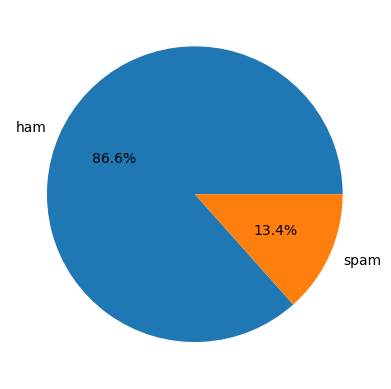

In [48]:
# sns.countplot(x=y)
data=y.value_counts()
data['ham']
plt.pie(data,labels=['ham','spam'],autopct='%1.1f%%')

Data Processing

In [49]:
from nltk.tokenize import word_tokenize 
from nltk.corpus import stopwords
from nltk.stem import LancasterStemmer, WordNetLemmatizer
from nltk import pos_tag

In [50]:
sent='Hello friends! How are you? I like Python Programming'

In [51]:
# toknize 
tokens1=word_tokenize(sent)

In [52]:
# remove punctuations and nos
tokens2=[token for token in tokens1 if token.isalpha()]

In [53]:
tokens2

['Hello', 'friends', 'How', 'are', 'you', 'I', 'like', 'Python', 'Programming']

In [54]:
# remove symbol

In [55]:
token3=[token for token in tokens2 if token.lower() not in stopwords.words('english')]

In [56]:
token3

['Hello', 'friends', 'like', 'Python', 'Programming']

In [57]:
# steam
from nltk.stem import PorterStemmer
ps=PorterStemmer()
tokens4=[ps.stem(token) for token in token3]
tokens4

['hello', 'friend', 'like', 'python', 'program']

In [58]:
def clean_text(sent):
    tokens1=word_tokenize(sent)
    tokens2=[token for token in tokens1 if token.isalpha()]
    tokens3=[token for token in tokens2 if token.lower() not in stopwords.words('English')]
    tokens4=[ps.stem(token) for token in tokens3]
    return tokens4

In [59]:
clean_text(sent)

['hello', 'friend', 'like', 'python', 'program']

In [60]:
sent1='It was an unexpected day rain during the play on ground'
clean_text(sent1)

['unexpect', 'day', 'rain', 'play', 'ground']

# day 5 code starts here

In [61]:
X.apply(clean_text)

0       [go, jurong, point, crazi, avail, bugi, n, gre...
1                            [ok, lar, joke, wif, u, oni]
2       [free, entri, wkli, comp, win, fa, cup, final,...
3           [u, dun, say, earli, hor, u, c, alreadi, say]
4            [nah, think, goe, usf, live, around, though]
                              ...                        
5567    [time, tri, contact, u, pound, prize, claim, e...
5568                       [ü, b, go, esplanad, fr, home]
5569                                [piti, mood, suggest]
5570    [guy, bitch, act, like, interest, buy, someth,...
5571                                   [rofl, true, name]
Name: text, Length: 5572, dtype: object

In [62]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer(analyzer=clean_text)

In [63]:
x_new=tfidf.fit_transform(X)
x_new.shape

(5572, 5926)

In [64]:
tfidf.get_feature_names_out()

array(['aa', 'aah', 'aaniy', ..., 'zyada', 'é', 'ü'], dtype=object)

In [65]:
len(tfidf.get_feature_names_out())

5926

In [66]:
x_new.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [67]:
from sklearn.model_selection import train_test_split

In [68]:
X_train,X_test,y_train,y_test=train_test_split(x_new,y,random_state=0)

In [69]:
X_train.shape

(4179, 5926)

In [70]:
X_test.shape

(1393, 5926)

- Train test split is also called as cross validation
- default size is 75% 25%

#### random state
- study it

##### Model Building

In [71]:
from sklearn.svm import SVC

In [72]:
svc_lin=SVC(kernel='linear')

In [73]:
svc_lin.fit(X_train,y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


performance evoluation

In [84]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,ConfusionMatrixDisplay

In [76]:
y_pred = svc_lin.predict(X_test)
accuracy_score(y_test,y_pred)

0.9827709978463748

In [80]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99      1208
        spam       0.99      0.88      0.93       185

    accuracy                           0.98      1393
   macro avg       0.98      0.94      0.96      1393
weighted avg       0.98      0.98      0.98      1393



In [83]:
confusion_matrix(y_test,y_pred)


array([[1206,    2],
       [  22,  163]])

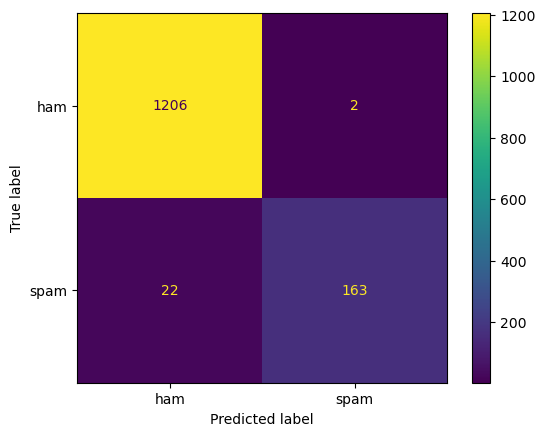

In [88]:
ConfusionMatrixDisplay.from_estimator(svc_lin,X_test,y_test)

In [90]:
svc_rbf = SVC(kernel='rbf')
svc_rbf.fit(X_train,y_train)
y_pred = svc_rbf.predict(X_test)
accuracy_score(y_test,y_pred)

0.9813352476669059

In [91]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99      1208
        spam       1.00      0.86      0.92       185

    accuracy                           0.98      1393
   macro avg       0.99      0.93      0.96      1393
weighted avg       0.98      0.98      0.98      1393



In [98]:
svc_poly = SVC(kernel='poly',degree=6)
svc_poly.fit(X_train,y_train)
y_pred = svc_poly.predict(X_test)
accuracy_score(y_test,y_pred)

0.9267767408470926

In [99]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         ham       0.92      1.00      0.96      1208
        spam       1.00      0.45      0.62       185

    accuracy                           0.93      1393
   macro avg       0.96      0.72      0.79      1393
weighted avg       0.93      0.93      0.91      1393



In [94]:
svc_sig = SVC(kernel='sigmoid')
svc_sig.fit(X_train,y_train)
y_pred = svc_sig.predict(X_test)
accuracy_score(y_test,y_pred)

0.9798994974874372

In [95]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99      1208
        spam       0.98      0.87      0.92       185

    accuracy                           0.98      1393
   macro avg       0.98      0.93      0.95      1393
weighted avg       0.98      0.98      0.98      1393



#### conclusion
Linear kernal is best for this data

In [126]:
f=open('sample.csv')
lines=f.readlines()

In [127]:
new_lines = tfidf.transform(lines)

In [128]:
lines

['Ok lar i double check wif da hair dresser already he said wun cut v short. He said will cut until i look nice.,,\n',
 'As a valued customer, I am pleased to advise you that following recent review of your Mob No. you are awarded with a £1500 Bonus Prize, call 09066364589\n',
 '"Today is ""song dedicated day.."" Which song will u dedicate for me? Send this to all ur valuable frnds but first rply me...",,\n']

In [ ]:
svc_lin.predict(new_lines)

array(['ham', 'spam', 'ham'], dtype=object)